In [ ]:
import pandas as pd
import numpy as np


from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline


from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from xgboost import XGBClassifier


from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [ ]:
df = pd.read_csv("Sleep_health_and_lifestyle_dataset (1).csv")
df.head()

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,NaN
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea


In [ ]:
df["Sleep Disorder"] = df["Sleep Disorder"].fillna("None")

In [ ]:
if "Person ID" in df.columns:
       df.drop(columns=["Person ID"], inplace=True)

In [ ]:
df["BMI Category"] = df["BMI Category"].replace({"Normal Weight": "Normal"})


# Split Blood Pressure
if "Blood Pressure" in df.columns:
       df[["Systolic_BP", "Diastolic_BP"]] = df["Blood Pressure"].str.split('/', expand=True).astype(int)
       df.drop(columns=["Blood Pressure"], inplace=True)

In [ ]:
X = df.drop(columns=["Sleep Disorder"])
y = df["Sleep Disorder"]

In [ ]:
le = LabelEncoder()
y_encoded = le.fit_transform(y)


print("Classes:", le.classes_)

Classes: ['Insomnia' 'None' 'Sleep Apnea']


In [ ]:
categorical_cols = X.select_dtypes(include="object").columns
numerical_cols = X.select_dtypes(exclude="object").columns


preprocessor = ColumnTransformer(
transformers=[
("num", StandardScaler(), numerical_cols),
("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)]
)

In [ ]:
rf_model = Pipeline([
("preprocessor", preprocessor),
("classifier", RandomForestClassifier(
n_estimators=200,
random_state=42
))
])

In [ ]:
xgb_model = Pipeline([
("preprocessor", preprocessor),
("classifier", XGBClassifier(
n_estimators=200,
learning_rate=0.05,
max_depth=5,
eval_metric='mlogloss',
random_state=42
))
])

In [ ]:
voting_clf = VotingClassifier(
estimators=[
('rf', rf_model),
('xgb', xgb_model)
],
voting='soft'
)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
X, y_encoded,
test_size=0.2,
stratify=y_encoded,
random_state=42
)

In [ ]:
voting_clf.fit(X_train, y_train)

,estimators,"[('rf', ...), ('xgb', ...)]"
,voting,'soft'
,weights,None
,n_jobs,None
,flatten_transform,True
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None


In [ ]:
y_pred = voting_clf.predict(X_test)


acc = accuracy_score(y_test, y_pred)
print(f"Final Accuracy: {acc*100:.2f}%")


print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, target_names=le.classes_))


print("Confusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))

Final Accuracy: 96.00%

Classification Report:

              precision    recall  f1-score   support

    Insomnia       0.88      0.93      0.90        15
        None       1.00      0.98      0.99        44
 Sleep Apnea       0.94      0.94      0.94        16

    accuracy                           0.96        75
   macro avg       0.94      0.95      0.94        75
weighted avg       0.96      0.96      0.96        75

Confusion Matrix:

[[14  0  1]
 [ 1 43  0]
 [ 1  0 15]]


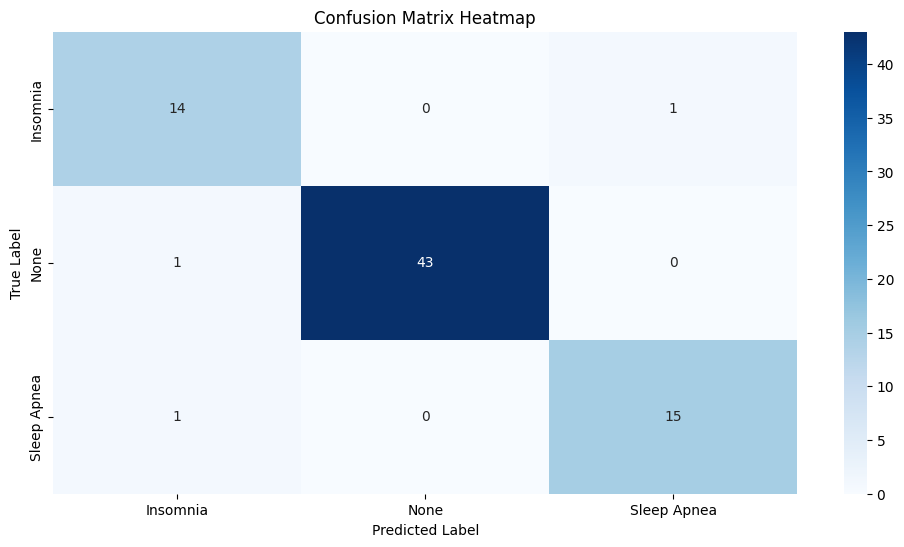

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns


cm = confusion_matrix(y_test, y_pred)


plt.figure(figsize=(12,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
xticklabels=le.classes_,
yticklabels=le.classes_)


plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix Heatmap')
plt.show()

PermutationExplainer explainer: 11it [00:17,  1.95s/it]                        


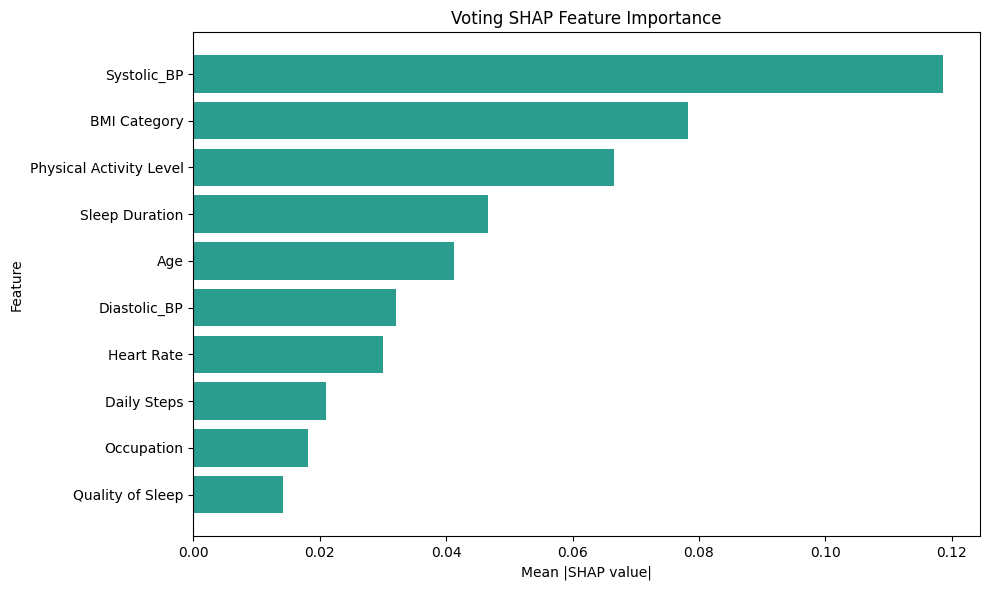

In [16]:
# Requires shap and lime; install from requirements.txt.
import shap

model_label = "Voting"
explain_model = voting_clf

feature_names = X_train.columns.tolist()
categorical_cols = X_train.select_dtypes(include=["object"]).columns.tolist()
numerical_cols = [col for col in feature_names if col not in categorical_cols]

# Encode categorical features so SHAP and LIME can work on the raw input space.
category_maps = {}
encoded_train = X_train.copy()
encoded_test = X_test.copy()

for col in categorical_cols:
    categories = list(pd.Index(X_train[col].astype(str).unique()))
    mapping = {value: idx for idx, value in enumerate(categories)}
    category_maps[col] = mapping
    encoded_train[col] = X_train[col].astype(str).map(mapping).astype(float)
    encoded_test[col] = X_test[col].astype(str).map(mapping).astype(float)


def decode_encoded_frame(encoded_array):
    encoded_array = np.asarray(encoded_array)
    if encoded_array.ndim == 1:
        encoded_array = encoded_array.reshape(1, -1)
    decoded = pd.DataFrame(encoded_array, columns=feature_names)
    for col in categorical_cols:
        inverse_map = {code: label for label, code in category_maps[col].items()}
        codes = pd.to_numeric(decoded[col], errors="coerce").fillna(0).round().astype(int)
        codes = codes.clip(0, len(inverse_map) - 1)
        decoded[col] = codes.map(inverse_map)
    for col in numerical_cols:
        decoded[col] = pd.to_numeric(decoded[col], errors="coerce")
    return decoded


def predict_proba_from_encoded(encoded_array):
    return explain_model.predict_proba(decode_encoded_frame(encoded_array))

encoded_train_array = encoded_train[feature_names].to_numpy(dtype=float)
encoded_test_array = encoded_test[feature_names].to_numpy(dtype=float)

background = shap.sample(encoded_train_array, min(30, len(encoded_train_array)), random_state=42)
sample_rows = encoded_test_array[:min(10, len(encoded_test_array))]

masker = shap.maskers.Independent(background)
shap_explainer = shap.Explainer(
    predict_proba_from_encoded,
    masker,
    feature_names=feature_names,
    algorithm="permutation",
)
shap_values = shap_explainer(sample_rows)

if shap_values.values.ndim == 3:
    mean_abs_shap = np.mean(np.abs(shap_values.values), axis=(0, 2))
else:
    mean_abs_shap = np.mean(np.abs(shap_values.values), axis=0)

shap_importance = pd.Series(mean_abs_shap, index=feature_names).sort_values(ascending=False)

top_shap = shap_importance.head(10).iloc[::-1]
plt.figure(figsize=(10, 6))
plt.barh(top_shap.index, top_shap.values, color="#2a9d8f")
plt.xlabel("Mean |SHAP value|")
plt.ylabel("Feature")
plt.title(f"{model_label} SHAP Feature Importance")
plt.tight_layout()
plt.show()


Actual label: Insomnia
Predicted label: Insomnia
Prediction probabilities: {'Insomnia': np.float64(0.9859), 'None': np.float64(0.0128), 'Sleep Apnea': np.float64(0.0013)}


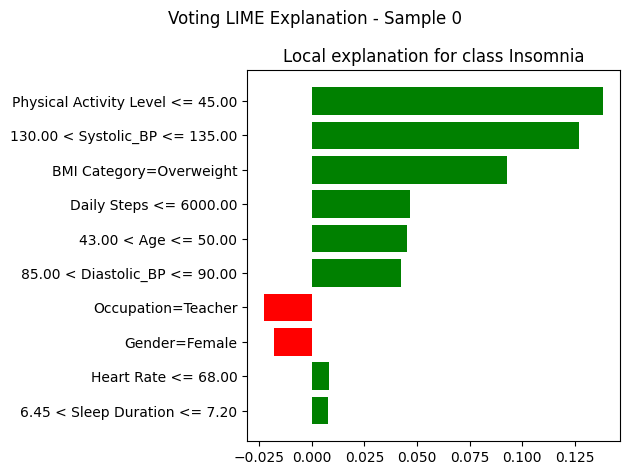

In [17]:
from lime.lime_tabular import LimeTabularExplainer

categorical_feature_indices = [feature_names.index(col) for col in categorical_cols]
categorical_names = {
    feature_names.index(col): list(category_maps[col].keys())
    for col in categorical_cols
}

lime_explainer = LimeTabularExplainer(
    training_data=encoded_train_array,
    feature_names=feature_names,
    class_names=list(le.classes_),
    categorical_features=categorical_feature_indices,
    categorical_names=categorical_names,
    mode="classification",
    discretize_continuous=True,
    random_state=42,
)

sample_idx = 0
sample_instance = encoded_test_array[sample_idx]
sample_probs = predict_proba_from_encoded(sample_instance)[0]
sample_pred_idx = int(np.argmax(sample_probs))
sample_pred_label = le.inverse_transform([sample_pred_idx])[0]
sample_true_label = le.inverse_transform([int(np.asarray(y_test)[sample_idx])])[0]

lime_exp = lime_explainer.explain_instance(
    sample_instance,
    predict_proba_from_encoded,
    num_features=min(10, len(feature_names)),
    top_labels=1,
)

print("Actual label:", sample_true_label)
print("Predicted label:", sample_pred_label)
print("Prediction probabilities:", dict(zip(le.classes_, np.round(sample_probs, 4))))

fig = lime_exp.as_pyplot_figure(label=sample_pred_idx)
fig.suptitle(f"{model_label} LIME Explanation - Sample {sample_idx}")
fig.tight_layout()
plt.show()


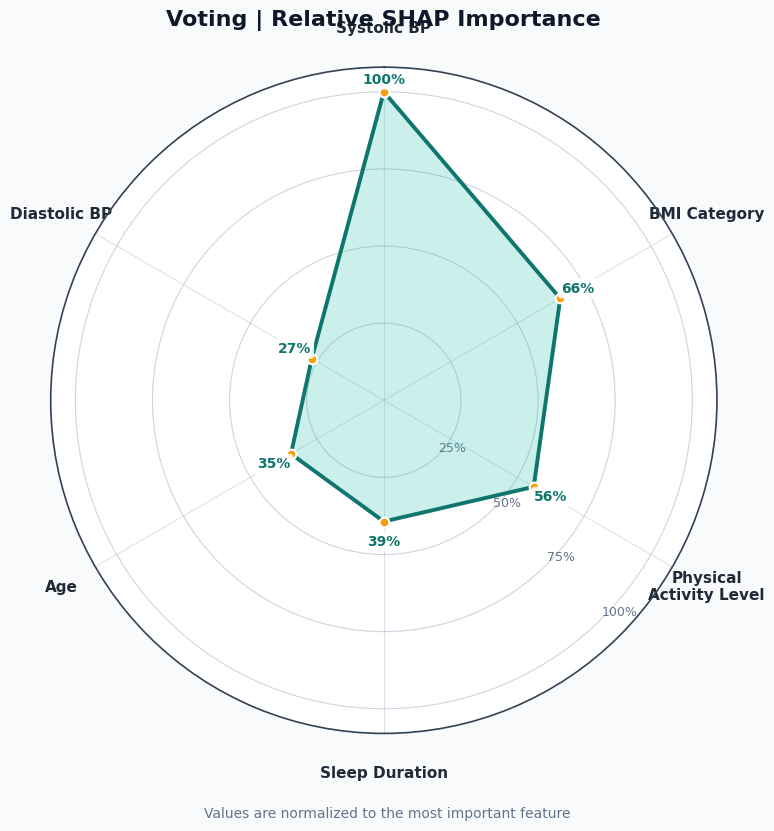

In [18]:
import textwrap

top_n = min(6, len(shap_importance))
radar_importance = shap_importance.head(top_n)
raw_values = radar_importance.to_numpy(dtype=float)
max_value = raw_values.max() if len(raw_values) else 0
radar_values = raw_values / max_value if max_value > 0 else np.zeros_like(raw_values)
radar_values_pct = radar_values * 100

angles = np.linspace(0, 2 * np.pi, top_n, endpoint=False)
closed_angles = np.concatenate([angles, [angles[0]]])
closed_values = np.concatenate([radar_values, [radar_values[0]]])
feature_labels = [textwrap.fill(str(name).replace("_", " "), width=14) for name in radar_importance.index]

fig, ax = plt.subplots(figsize=(9, 9), subplot_kw={"polar": True})
fig.patch.set_facecolor("#f8fafc")
ax.set_facecolor("#ffffff")
ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)
ax.plot(closed_angles, closed_values, color="#0f766e", linewidth=2.8, marker="o", markersize=7, markerfacecolor="#f59e0b", markeredgecolor="white", markeredgewidth=1.5, zorder=3)
ax.fill(closed_angles, closed_values, color="#14b8a6", alpha=0.22, zorder=2)
ax.set_xticks(angles)
ax.set_xticklabels(feature_labels, fontsize=11, fontweight="semibold", color="#1f2937")
ax.tick_params(axis="x", pad=18)
ax.set_ylim(0, 1.08)
ax.set_yticks([0.25, 0.50, 0.75, 1.00])
ax.set_yticklabels(["25%", "50%", "75%", "100%"], fontsize=9, color="#64748b")
ax.set_rlabel_position(135)
ax.yaxis.grid(True, color="#94a3b8", alpha=0.45, linewidth=0.8)
ax.xaxis.grid(True, color="#cbd5e1", alpha=0.65, linewidth=0.8)
ax.spines["polar"].set_color("#334155")
ax.spines["polar"].set_linewidth(1.2)
for angle, value in zip(angles, radar_values_pct):
    ax.text(angle, min(value / 100 + 0.065, 1.04), f"{value:.0f}%", ha="center", va="center", fontsize=10, fontweight="bold", color="#0f766e", bbox={"boxstyle": "round,pad=0.22", "facecolor": "white", "edgecolor": "none", "alpha": 0.85})
ax.set_title(f"{model_label} | Relative SHAP Importance", fontsize=16, fontweight="bold", color="#0f172a", pad=30)
fig.text(0.5, 0.035, "Values are normalized to the most important feature", ha="center", fontsize=10, color="#64748b")
plt.tight_layout(rect=[0, 0.06, 1, 0.95])
plt.show()
